<a href="https://colab.research.google.com/github/chinmaynaik-hub/covid_19_death_predictor_project/blob/main/covid_19_death_predictor_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Titile of the project:

#**covid 19 Death prediction project**

##### prerequisites of the project:

- Dataset : Countrywise Covid 19 dataset choosen from kaggle
- language : python for programming
- type of prediction : Regression
- models : linear regression, knnregssor, decision tree.
- Aim for accuracy : greater than 90%


#### Aim
+ to predict the occurances of deaths from covid 19 using avilable data.
+ by using the columns like Confirmed, Deaths, Recovered, Active, detaths/100, recovered/100.
+ using visualization tools for checking the correctness of the model prediction
+ using coefficeient of determination (r square score) for checking the model correctness in prediction.

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
#reading csv dataseet file using pandas library
covidData=pd.read_csv('/content/country_wise_latest_covid19.csv')

In [ ]:
covidData.isna().sum()  #checking for null values in the dataset

,0
Country/Region,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
New cases,0
New deaths,0
New recovered,0
Deaths / 100 Cases,0
Recovered / 100 Cases,0


In [ ]:
covidData.head() #understand the data

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


> using label encoder to convert categorical data to numerical data

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

covidData[["Country/Region","WHO Region"]]=covidData[["Country/Region","WHO Region"]].apply(le.fit_transform)

> finding correlation matrix to find out the x variable according to choosen y variable (Deaths in this case)

In [ ]:
covidData.corr()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
Country/Region,1.000000,0.057151,0.066606,0.004157,0.094585,0.032091,0.022273,-0.008903,0.052931,-0.038300,0.108756,0.061760,0.021385,-0.036269,0.059632
Confirmed,0.057151,1.000000,0.934698,0.906377,0.927018,0.909720,0.871683,0.859252,0.063550,-0.064815,0.025175,0.999127,0.954710,-0.010161,-0.016127
Deaths,0.066606,0.934698,1.000000,0.832098,0.871586,0.806975,0.814161,0.765114,0.251565,-0.114529,0.169006,0.939082,0.855330,-0.034708,-0.005803
Recovered,0.004157,0.906377,0.832098,1.000000,0.682103,0.818942,0.820338,0.919203,0.048438,0.026610,-0.027277,0.899312,0.910013,-0.013697,-0.001206
Active,0.094585,0.927018,0.871586,0.682103,1.000000,0.851190,0.781123,0.673887,0.054380,-0.132618,0.058386,0.931459,0.847642,-0.003752,-0.027519
New cases,0.032091,0.909720,0.806975,0.818942,0.851190,1.000000,0.935947,0.914765,0.020104,-0.078666,-0.011637,0.896084,0.959993,0.030791,-0.009019
New deaths,0.022273,0.871683,0.814161,0.820338,0.781123,0.935947,1.000000,0.889234,0.060399,-0.062792,-0.020750,0.862118,0.894915,0.025293,-0.062608
New recovered,-0.008903,0.859252,0.765114,0.919203,0.673887,0.914765,0.889234,1.000000,0.017090,-0.024293,-0.023340,0.839692,0.954321,0.032662,-0.021902
Deaths / 100 Cases,0.052931,0.063550,0.251565,0.048438,0.054380,0.020104,0.060399,0.017090,1.000000,-0.168920,0.334594,0.069894,0.015095,-0.134534,0.015550
Recovered / 100 Cases,-0.038300,-0.064815,-0.114529,0.026610,-0.132618,-0.078666,-0.062792,-0.024293,-0.168920,1.000000,-0.295381,-0.064600,-0.063013,-0.394254,0.214888


In [ ]:
covidData.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,0,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,2
1,1,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,3
2,2,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,0
3,3,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,3
4,4,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,0


In [ ]:
covidData.tail()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
182,182,10621,78,3752,6791,152,2,0,0.73,35.33,2.08,8916,1705,19.12,2
183,183,10,1,8,1,0,0,0,10.00,80.00,12.50,10,0,0.00,0
184,184,1691,483,833,375,10,4,36,28.56,49.26,57.98,1619,72,4.45,2
185,185,4552,140,2815,1597,71,1,465,3.08,61.84,4.97,3326,1226,36.86,0
186,186,2704,36,542,2126,192,2,24,1.33,20.04,6.64,1713,991,57.85,0


In [ ]:
covidData.shape #cheching the shape of data for better understanding

(187, 15)

In [ ]:
covidData.corr()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
Country/Region,1.000000,0.057151,0.066606,0.004157,0.094585,0.032091,0.022273,-0.008903,0.052931,-0.038300,0.108756,0.061760,0.021385,-0.036269,0.059632
Confirmed,0.057151,1.000000,0.934698,0.906377,0.927018,0.909720,0.871683,0.859252,0.063550,-0.064815,0.025175,0.999127,0.954710,-0.010161,-0.016127
Deaths,0.066606,0.934698,1.000000,0.832098,0.871586,0.806975,0.814161,0.765114,0.251565,-0.114529,0.169006,0.939082,0.855330,-0.034708,-0.005803
Recovered,0.004157,0.906377,0.832098,1.000000,0.682103,0.818942,0.820338,0.919203,0.048438,0.026610,-0.027277,0.899312,0.910013,-0.013697,-0.001206
Active,0.094585,0.927018,0.871586,0.682103,1.000000,0.851190,0.781123,0.673887,0.054380,-0.132618,0.058386,0.931459,0.847642,-0.003752,-0.027519
New cases,0.032091,0.909720,0.806975,0.818942,0.851190,1.000000,0.935947,0.914765,0.020104,-0.078666,-0.011637,0.896084,0.959993,0.030791,-0.009019
New deaths,0.022273,0.871683,0.814161,0.820338,0.781123,0.935947,1.000000,0.889234,0.060399,-0.062792,-0.020750,0.862118,0.894915,0.025293,-0.062608
New recovered,-0.008903,0.859252,0.765114,0.919203,0.673887,0.914765,0.889234,1.000000,0.017090,-0.024293,-0.023340,0.839692,0.954321,0.032662,-0.021902
Deaths / 100 Cases,0.052931,0.063550,0.251565,0.048438,0.054380,0.020104,0.060399,0.017090,1.000000,-0.168920,0.334594,0.069894,0.015095,-0.134534,0.015550
Recovered / 100 Cases,-0.038300,-0.064815,-0.114529,0.026610,-0.132618,-0.078666,-0.062792,-0.024293,-0.168920,1.000000,-0.295381,-0.064600,-0.063013,-0.394254,0.214888


>Defining x and y variable

In [ ]:
x=covidData[["Confirmed","Recovered","Active","New cases","New deaths","New recovered"]] #should be written in 2d array format
y=covidData[["Deaths"]]

In [ ]:
#dividing data into training data and testing data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2) #here 20% data is used for testing.

> training of model on data

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression() #linear regresson model is used for prediction
lr.fit(x_train,y_train) #training of model on data

LinearRegression()

In [ ]:
# newResult=lr.predict(10621,3752,6791,152,2,0)

> using r2 score checking the coefficient of determination

In [ ]:
from sklearn.metrics import r2_score
y_pred=lr.predict(x_test) #prediction of result on test data

In [ ]:
print(r2_score(y_test,y_pred)) # r2 score is generated

1.0


In [ ]:
import numpy as np
import pandas as pd

# x_train.columns: ['Confirmed', 'Recovered', 'New recovered', 'New deaths', 'New cases', 'Active']

feature_names = x_train.columns.tolist()

#converting the data into numpy array
input_data_array = np.array([[10621,3752,6791,152,2,0]])
#converting numpy array into pandas dataframe because of its easier evaluation in row and column types
input_data_df = pd.DataFrame(input_data_array, columns=feature_names)


#prediction of new result
newResult = lr.predict(input_data_df)
print(f"Predicted Deaths: {newResult[0][0]:.2f}")

Predicted Deaths: 78.00


> using visualization tools for model prediction score


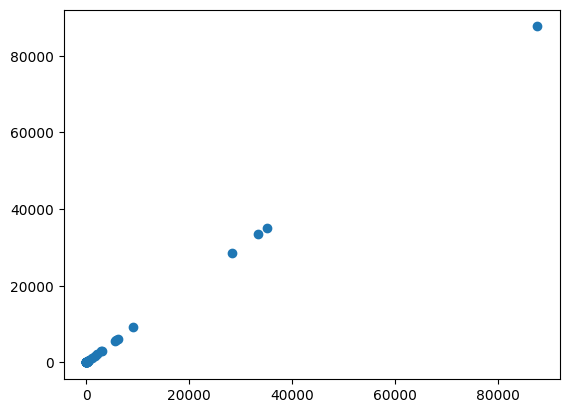

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred) #scatterplot is used

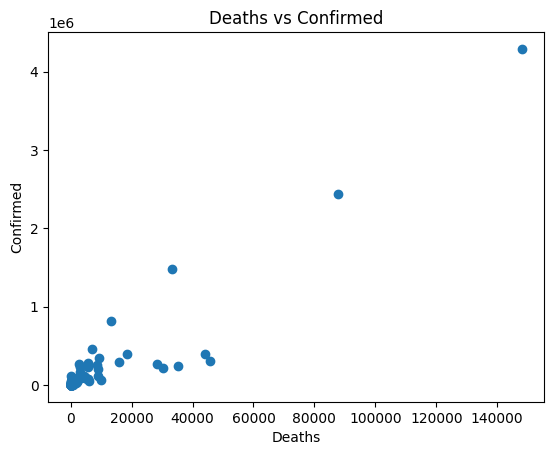

In [ ]:
#deaths vs confirmed scatterplot
import matplotlib.pyplot as plt

plt.scatter(covidData.Deaths, covidData.Confirmed)
plt.xlabel('Deaths')
plt.ylabel('Confirmed')
plt.title('Deaths vs Confirmed')
plt.show()

###using KNN model for training the data

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=10)
knn.fit(x_train, y_train) #model training
knn_y_pred=knn.predict(x_test) #prediction of result on unknown values

> Here the coefficient of determination value of KNN algorithm is very less compared to previously used linear regression model

In [ ]:
print(r2_score(y_test,knn_y_pred)) #finding coefficient of determination

0.3756014737745079


Predicion of result

In [ ]:
input_data_array = np.array([[10621,3752,6791,152,2,0]])
input_data_df = pd.DataFrame(input_data_array, columns=feature_names)

newResult_knn = knn.predict(input_data_df)
print(f"Predicted Deaths: {newResult_knn[0][0]:.2f}")

Predicted Deaths: 262.20


> The KNN model predicts deaths which is not accurate because of less coefficient of determination score

#decision tree


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)# training of data

DecisionTreeRegressor()

In [ ]:
dt_predict=dt.predict(x_test) # prediction of new value

In [ ]:
print(r2_score(y_test,dt_predict)) # finding coefficient of determination

0.24308178082873255


# conclusion

- among all the above 3 models, linear regression has higher coefficient of determination.
- the result predicted by other 2 models are not accurate and not usable.